In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image
import requests
from io import BytesIO

c:\Users\Humera Siddiqua\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Humera Siddiqua\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


Loading the image

Image loaded successfully!
Image shape: (64, 64, 3)


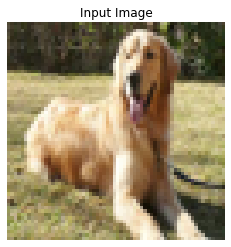

In [2]:
img = Image.open("image/input_image.jpg").convert("RGB")
img = img.resize((64, 64))
img_array = np.array(img)

print("Image loaded successfully!")
print("Image shape:", img_array.shape)  # Should be (64, 64, 3)

plt.imshow(img_array)
plt.title("Input Image")
plt.axis('off')
plt.show()

converting 2D image to 3D volume

In [3]:
depth = 8
img_3d = np.stack([img_array] * depth, axis=0)  # (8, 64, 64, 3)
img_3d = img_3d / 255.0                          # normalize 0 to 1
img_3d_batch = np.expand_dims(img_3d, axis=0)    # (1, 8, 64, 64, 3)

print("Original image shape  :", img_array.shape)
print("After stacking (3D)   :", img_3d.shape)
print("After adding batch dim:", img_3d_batch.shape)

Original image shape  : (64, 64, 3)
After stacking (3D)   : (8, 64, 64, 3)
After adding batch dim: (1, 8, 64, 64, 3)


Building the cnn model

In [4]:
model = models.Sequential([

    # Conv Layer 1 - learns basic features
    layers.Conv3D(32, kernel_size=(3,3,3), activation='relu',
                  padding='same', input_shape=(8, 64, 64, 3)),

    # Pooling Layer 1 - reduces size by half
    layers.MaxPooling3D(pool_size=(2,2,2)),

    # Conv Layer 2 - learns complex features
    layers.Conv3D(64, kernel_size=(3,3,3), activation='relu',
                  padding='same'),

    # Pooling Layer 2 - reduces size again
    layers.MaxPooling3D(pool_size=(2,2,2)),

    # Conv Layer 3 - learns highest level features
    layers.Conv3D(128, kernel_size=(3,3,3), activation='relu',
                  padding='same'),

    # Global Average Pooling - summarizes everything
    layers.GlobalAveragePooling3D(),

    # Final output layers
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

c:\Users\Humera Siddiqua\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 8, 64, 64, 32)  │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 4, 32, 32, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 4, 32, 32, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 2, 16, 16, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 2, 16, 16, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,202 (1.10 MB)

 Trainable params: 288,202 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

Printing layer by layer shape

In [5]:
print("Layer-by-Layer Shape Progression:")
print("-" * 50)

x = img_3d_batch
for layer in model.layers:
    x = layer(x)
    print(f"{layer.name:40s} → {str(x.shape)}")

Layer-by-Layer Shape Progression:
--------------------------------------------------
conv3d                                   → (1, 8, 64, 64, 32)
max_pooling3d                            → (1, 4, 32, 32, 32)
conv3d_1                                 → (1, 4, 32, 32, 64)
max_pooling3d_1                          → (1, 2, 16, 16, 64)
conv3d_2                                 → (1, 2, 16, 16, 128)
global_average_pooling3d                 → (1, 128)
dense                                    → (1, 64)
dense_1                                  → (1, 10)


Printing global average pooling output

In [6]:
gap_model = models.Sequential(model.layers[:-2])

gap_output = gap_model.predict(img_3d_batch)

print("GAP Output Shape:", gap_output.shape)   
print("First 10 values :", np.round(gap_output[0][:10], 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
GAP Output Shape: (1, 128)
First 10 values : [4.000e-04 4.870e-02 3.200e-03 4.280e-02 1.728e-01 0.000e+00 1.000e-04
 2.300e-03 1.170e-01 7.000e-04]


Visualizing GAP output as Bar chart

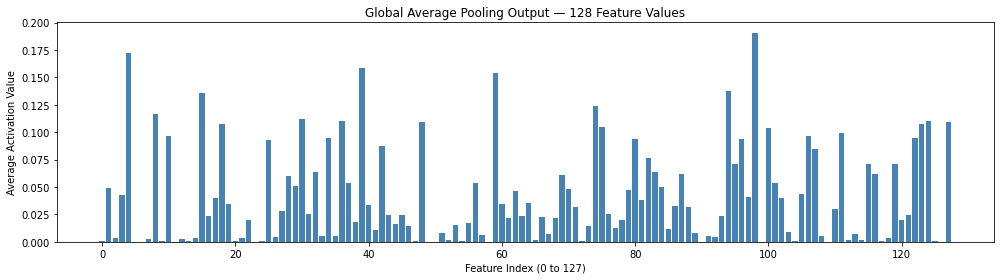


Done! GAP successfully extracted 128 features from your image.


In [7]:
plt.figure(figsize=(14, 4))
plt.bar(range(len(gap_output[0])), gap_output[0], color='steelblue')
plt.title("Global Average Pooling Output — 128 Feature Values")
plt.xlabel("Feature Index (0 to 127)")
plt.ylabel("Average Activation Value")
plt.tight_layout()
plt.show()

print("\nDone! GAP successfully extracted", len(gap_output[0]), "features from your image.")